# Detecting Misinformation with AI
### INFO 629 — Final Project Report
**Author:** Rajat Sharma  
**Date:** June 2026  

---

## Table of Contents
1. [Why — Problem Statement and Motivation](#1-why)
2. [What — Data, Techniques, and Domain](#2-what)
3. [Who — Stakeholders and Use Cases](#3-who)
4. [How — Development Decisions and Steps](#4-how)
5. [How Good — Evaluation and Results](#5-how-good)
6. [Where — Storage and Deployment](#6-where)
7. [Experiences — Reflections and Future Work](#7-experiences)

---
## 1. Why — Problem Statement and Motivation <a id='1-why'></a>

### 1.1 The Misinformation Problem

A landmark 2018 MIT study ([Vosoughi et al., *Science*](https://www.science.org/doi/10.1126/science.aap9559)) found that false news spreads **six times faster** on social media than true news, and reaches a substantially larger audience before any correction is issued. By the time a fact-check is published, the original story may have already reached millions of people. The 2016 US election cycle, the COVID-19 pandemic, and subsequent geopolitical events demonstrated that large-scale disinformation can affect public health decisions, financial markets, and democratic processes.

Human fact-checkers cannot operate at the speed and volume required. Major platforms publish hundreds of millions of posts per day; professional fact-checking organisations can review at most a few dozen claims per day each. Automated detection is therefore a necessary — if imperfect — first line of defence.

### 1.2 Project Goals

This project addresses two research questions:

**RQ1 — Performance:** How accurately do classical machine learning, deep learning, and transformer models classify fake news across multiple benchmark datasets?

**RQ2 — Generalisation:** Do models trained on one dataset or domain generalise to unseen sources, different publication styles, and different text lengths? What is the primary barrier to cross-domain transfer?

### 1.3 Expected Impact

A model that genuinely learns linguistic markers of misinformation — rather than memorising outlet-specific writing styles — could serve as a scalable pre-screening tool that routes suspicious content to human reviewers. Understanding *why* existing models fail at cross-domain transfer is equally valuable: it provides concrete guidance on dataset construction and training strategy for the next generation of detection systems.

---
## 2. What — Data, AI Techniques, and Domain <a id='2-what'></a>

### 2.1 Domain

The project sits at the intersection of **Natural Language Processing (NLP)** and **computational journalism**. The task is text classification: given the headline and body of a news article (or a short claim/tweet), predict whether the content is reliable or misleading. The project intentionally spans multiple sub-tasks — binary article classification, six-class political claim veracity, and tweet-level rumour verification — to stress-test generalisation.

### 2.2 Datasets

Five datasets were used, each serving a distinct purpose.

| Dataset | Size | Label type | Primary use |
|---|---|---|---|
| ISOT | 39,076 articles | Binary (fake / real) | Main training benchmark |
| WELFake | 63,644 articles | Binary (fake / real) | Cross-source training benchmark |
| LIAR | 12,791 claims | 6-class veracity | Political fact-checking sub-task |
| NELA-GT (sampled) | 500,000 articles | 3-class (Reliable / Questionable / Conspiracy) | Source-diversity training |
| PHEMEplus | 1,401 rumour threads | Binary (false / true rumour) | Out-of-domain (tweet) evaluation |

#### ISOT
~39,000 English news articles scraped between 2016 and 2017. Real articles are **exclusively from Reuters**; fake articles are from a curated list of unreliable websites flagged by PolitiFact and Wikipedia. The dataset is widely used in the literature and serves as a clean, high-signal benchmark. The single-source structure of the real class is a known limitation addressed later in this report.

**Split (80/10/10 stratified):** 31,260 train / 3,908 val / 3,908 test  
**Label balance (train):** Fake = 14,320 (46%) / Real = 16,940 (54%)

#### WELFake
~64,000 articles assembled from four existing datasets: Kaggle Fake News, McIntire, Reuters, and BuzzFeed Political. The multi-source composition produces more varied writing styles than ISOT, although Reuters articles are still the dominant real-news source (~62% of real-class articles).

**Split (80/10/10 stratified):** 50,915 train / 6,364 val / 6,365 test  
**Label balance (train):** Fake = 27,814 (55%) / Real = 23,101 (45%)

#### LIAR
12,791 short political statements from PolitiFact, each annotated with one of six veracity labels: *pants-on-fire, false, barely-true, half-true, mostly-true, true*. Statements average ~18 words. The dataset also includes rich metadata: speaker identity, party affiliation, subject tags, state, and the speaker's historical truthfulness record across prior PolitiFact rulings. Published state-of-the-art (text-only) is approximately 30% macro-F1, reflecting the genuine difficulty of distinguishing six fine-grained veracity levels from short text alone.

**Split (canonical):** 10,240 train / 1,284 val / 1,267 test  
**Label balance (train):** Roughly uniform across 6 classes (839–2,114 per class)

#### NELA-GT (Sampled 500k)
NELA-GT is a multi-year corpus of ~4.2 million articles from 488 publishers, annotated at the **publisher level** using Media Bias / Fact Check (MBFC) ratings. Publisher ratings are mapped to three classes: Reliable (MBFC categories: Left, Left-Center, Least Biased, Right-Center, Right, Pro-Science), Questionable (MBFC: Questionable Source), and Conspiracy (MBFC: Conspiracy-Pseudoscience). Satire-rated publishers are excluded because satire is a distinct genre rather than misinformation.

A stratified subsample of 500,000 articles was drawn across all 457 publishers with usable MBFC labels using 3-pass reservoir sampling to avoid loading the full 13 GB corpus into memory.

**Split (80/10/10 stratified):** 399,938 train / 50,018 val / 50,044 test  
**Label balance (train):** Reliable = 289,512 (72%) / Questionable = 76,780 (19%) / Conspiracy = 33,646 (8%)  
**The class imbalance reflects the real-world MBFC publisher landscape** — the majority of publishers are rated as reliable.

#### PHEMEplus
1,401 verified rumour threads from five breaking-news Twitter events: Charlie Hebdo attack, Ferguson protests, Germanwings crash, Ottawa shooting, and Sydney siege. Each thread consists of a source tweet and its reply tree; only the source tweet text is used for classification. Labels are derived from post-hoc crowd annotation: *true rumour* → 1 (Real), *false rumour* → 0 (Fake). Unverified threads are excluded. PHEMEplus is used exclusively as an **out-of-domain evaluation** target — no model is trained on it.

**Total:** 1,401 threads (fake = 393 / real = 1,008)  
**Key domain gap:** Tweet-length text (~15–25 words) vs. article-length text (~300–1,000 words).

### 2.3 Data Sources and Collection

- ISOT: Published by University of Victoria, available on Kaggle.
- WELFake: Published by Verma et al. (2021), available on Kaggle.
- LIAR: Published by Wang (2017), available from the University of California Santa Barbara NLP group.
- NELA-GT: Published by Gruppi et al. (2022), distributed via HuggingFace (`ioverho/misinfo-general`). Downloaded using `huggingface-cli` and stored locally as Parquet shards by year (2017–2022).
- PHEMEplus: Published by Zubiaga et al. (2016), downloaded from Figshare.

### 2.4 AI Techniques Applied

Three tiers of classification technique were evaluated:

1. **Classical ML** — TF-IDF feature extraction with Logistic Regression, LinearSVC, Random Forest, and XGBoost.
2. **Deep Learning** — GloVe pre-trained word embeddings with BiLSTM and TextCNN architectures.
3. **Transformers** — Fine-tuned BERT-base-uncased and RoBERTa-base.

In addition, SHAP (SHapley Additive exPlanations) was used for model interpretability on TF-IDF classifiers.

---
## 3. Who — Stakeholders and Use Cases <a id='3-who'></a>

### 3.1 Primary Stakeholders

| Stakeholder | Need | How this project addresses it |
|---|---|---|
| Social media platforms | Pre-screen flagged content before human review | Classical and DL models offer sub-millisecond to 20ms inference; suitable for real-time pipelines |
| Newsroom fact-checkers | Prioritise which stories warrant investigation | Ranking articles by predicted unreliability score reduces manual triage |
| Researchers and educators | Understand model limitations and failure modes | Cross-dataset probes and SHAP analysis surface the source-fingerprinting problem transparently |
| Policy makers | Assess the state of automated fact-checking | Generalisation results on NELA and PHEMEplus provide an honest (rather than inflated) accuracy picture |

### 3.2 Use Cases

**Content moderation pipeline:** A platform API scores incoming articles in real time. Articles above a threshold are queued for human review rather than immediately removed, preserving editorial judgement.

**Browser extension:** A lightweight LR or TextCNN model (0.44–0.76 ms inference) could run client-side or via a thin API to annotate news links as a user browses.

**Research benchmark:** The cross-dataset probe design (train on one source, evaluate on another without retraining) provides a standard protocol for measuring true generalisation rather than within-distribution accuracy.

---
## 4. How — Development Decisions and Steps <a id='4-how'></a>

### 4.1 Preprocessing Pipeline

All datasets share a common cleaning pipeline, with dataset-specific extensions for NELA-GT.

In [1]:
# Preprocessing — representative snippet from src/utils/data_loader.py
import re, nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

STOP_WORDS = set(stopwords.words('english'))

def clean_text(text: str) -> str:
    """Shared cleaning step applied to all datasets."""
    text = re.sub(r'<[^>]+>', ' ', text)          # strip HTML
    text = re.sub(r'http\S+|www\S+', '', text)    # remove URLs
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t.isalpha() and t not in STOP_WORDS]
    return ' '.join(tokens)

def make_text_column(df, title_col='title', body_col='text'):
    """Concatenate headline + body into a single 'text' field."""
    return df[title_col].fillna('') + ' ' + df[body_col].fillna('')

**Steps applied to every dataset:**
1. **Text extraction** — headline and article body concatenated into a single `text` field.
2. **Cleaning** — HTML tags, URLs stripped; lowercased; tokenised with NLTK; stopwords removed.
3. **Label encoding** — dataset-specific (see below).
4. **Stratified splits** — 80% train / 10% validation / 10% test, stratified by label.
5. **Tier-specific feature extraction** — TF-IDF for classical models; GloVe token IDs for DL; AutoTokenizer for transformers.

**NELA-GT extensions:**
- Labels derived from MBFC publisher ratings stored in a DuckDB metadata database, not from article-level annotation.
- Parallel shard processing with `ProcessPoolExecutor` (one worker per year-shard, RAM-capped) to handle the 4.2M article corpus.
- Streaming deduplication using a hash set — required because the merged CSV exceeds 13 GB, too large for in-memory `pandas.read_csv`.
- 3-pass reservoir sampling to draw 500,000 articles proportionally across all 457 publishers without loading the full corpus.

### 4.2 Label Encoding

| Dataset | Labels | Encoding |
|---|---|---|
| ISOT / WELFake | Fake / Real | 0 = Fake, 1 = Real |
| LIAR | pants-on-fire, false, barely-true, half-true, mostly-true, true | 0–5 (ordinal) |
| NELA-GT | Reliable, Questionable, Conspiracy | 0, 1, 2 |
| PHEMEplus | false rumour, true rumour | 0, 1 |

For **NELA cross-dataset evaluation** against binary targets (ISOT, WELFake, PHEMEplus), a binary collapse is applied: Reliable (0) → Real (1); Questionable (1) + Conspiracy (2) → Fake (0). Probabilities are collapsed as P(Fake) = P(class=1) + P(class=2).

### 4.3 Classical Models — Feature Engineering

TF-IDF was chosen because it is interpretable (features are vocabulary tokens), fast at inference, and provides a strong baseline that reveals dataset-specific artefacts.

In [2]:
# TF-IDF setup — from src/classical/features.py
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=50_000,    # top 50k tokens by corpus frequency
    ngram_range=(1, 2),     # unigrams + bigrams
    sublinear_tf=True,      # log-normalise term frequencies
    min_df=3,               # ignore very rare terms
    strip_accents='unicode',
    analyzer='word',
    stop_words=None,        # stopwords already removed in cleaning
)

**Model-specific decisions:**

- **Logistic Regression:** L2 regularisation, `max_iter=1000`, `C=1.0`. Chosen as the primary interpretable baseline; fast, probabilistic, compatible with LinearExplainer for SHAP.
- **LinearSVC:** Hinge loss, `C=0.1`. Faster than kernel SVC at scale; wrapped in `CalibratedClassifierCV` to produce probabilities for AUC computation.
- **Random Forest:** `n_estimators=100`, `max_features='sqrt'`, `n_jobs=4`. The `max_features='sqrt'` setting is critical — without it, each split evaluates all 50,000 TF-IDF features, causing OOM on large datasets. For NELA (400k rows), further reduced to `n_estimators=50, max_samples=0.5` to fit in RAM.
- **XGBoost:** `n_estimators=200`, `max_depth=6`, `learning_rate=0.1`, tree method `hist` for sparse input efficiency.

### 4.4 Deep Learning Models

GloVe 840B-token, 300-dimensional pre-trained embeddings were used. The vocabulary was built from the training corpus (top 30,000 tokens by frequency) with a coverage of 95.1% on the NELA-sampled set.

In [3]:
# BiLSTM architecture — from src/deep_learning/models.py
import torch.nn as nn

class BiLSTM(nn.Module):
    def __init__(self, embedding_matrix, num_classes=2, hidden=256, layers=2, dropout=0.3):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.embedding.weight = nn.Parameter(embedding_matrix)
        self.lstm = nn.LSTM(embed_dim, hidden, num_layers=layers,
                            batch_first=True, bidirectional=True,
                            dropout=dropout if layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden * 2, num_classes)  # *2 for bidirectional

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        _, (hn, _) = self.lstm(emb)
        # concatenate last hidden state from both directions
        out = torch.cat([hn[-2], hn[-1]], dim=1)
        return self.fc(self.dropout(out))

In [4]:
# TextCNN architecture — from src/deep_learning/models.py
class TextCNN(nn.Module):
    def __init__(self, embedding_matrix, num_classes=2, num_filters=128, filter_sizes=(2,3,4,5)):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.embedding.weight = nn.Parameter(embedding_matrix)
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, fs) for fs in filter_sizes
        ])
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(num_filters * len(filter_sizes), num_classes)

    def forward(self, x):
        emb = self.embedding(x).permute(0, 2, 1)  # (B, D, L)
        pooled = [F.relu(conv(emb)).max(dim=2).values for conv in self.convs]
        out = torch.cat(pooled, dim=1)
        return self.fc(self.dropout(out))

**Training configuration (DL):**
- Optimiser: Adam, `lr=1e-3`, weight decay `1e-5`
- Batch size: 64 (ISOT/WELFake), 128 (NELA)
- Early stopping: patience=3 epochs on validation macro-F1
- Max sequence length: 512 tokens (truncated or padded)
- Hardware: Local RTX 4080 Super (ISOT/WELFake); Google Colab A100 (NELA 500k)

**Frozen vs. finetuned:** In the *frozen* variant, the embedding layer weights are held fixed and only the classification head is trained. In the *finetuned* variant, all weights (including embeddings) are updated. Finetuned consistently outperforms frozen by 0.0–0.003 F1 on binary datasets, confirming that domain adaptation in the embedding space provides marginal gains when GloVe coverage is already high.

### 4.5 Transformer Models

In [5]:
# Transformer classifier — from src/transformers_/models.py
from transformers import AutoModel
import torch.nn as nn

class TransformerClassifier(nn.Module):
    def __init__(self, model_name: str, num_classes: int = 2, dropout: float = 0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden = self.encoder.config.hidden_size  # 768 for base models
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled = outputs.last_hidden_state[:, 0, :]  # CLS token
        return self.classifier(self.dropout(pooled))

**Training configuration (Transformers):**
- Optimiser: AdamW, `lr=2e-5`
- Batch size: 32, gradient accumulation × 2
- Max sequence length: 512 tokens (HuggingFace AutoTokenizer)
- Early stopping: patience=2 on validation macro-F1
- Hardware: RTX 4080 Super

Models: `bert-base-uncased` (110M params) and `roberta-base` (125M params). Both evaluated in frozen (encoder fixed, head only) and finetuned variants.

### 4.6 Evaluation Protocol

Three evaluation types were used:

1. **Within-dataset:** Train and test on the same dataset's splits. Standard held-out test set.
2. **Cross-dataset probe:** Train on dataset A, evaluate on dataset B's test set without any fine-tuning on B. Measures genuine domain transfer.
3. **Out-of-domain (OOD):** Evaluate on PHEMEplus — a completely different modality (tweets), never seen during training.

**Primary metrics:** Macro-F1 (equal weight per class; robust to imbalance), ROC-AUC.  
**Secondary metrics:** Accuracy, per-class precision/recall/F1, inference latency (ms/sample, CPU, single-sample batch).

All results are saved as timestamped JSON files in `results/runs/` and aggregated by `src/utils/results_aggregator.py`.

In [6]:
# Load and display the aggregated results table
import pandas as pd
import json, os

with open('../results/aggregated_results.json') as f:
    results = json.load(f)

print(f"Total result records loaded: {len(results)}")
df_all = pd.DataFrame(results)
print(f"Unique models: {df_all['model_name'].nunique()}")
print(f"Datasets covered: {sorted(df_all['dataset_name'].unique())}")

Total result records loaded: 207
Unique models: 95
Datasets covered: ['combined', 'isot', 'liar', 'nela_sampled_500k', 'pheme', 'phemeplus', 'welfake']


---
## 5. How Good — Evaluation and Results <a id='5-how-good'></a>

### 5.1 Evaluation Metrics

**Macro-F1** is the primary metric throughout. It is the unweighted mean of per-class F1 scores, making it robust to class imbalance. For binary tasks, Macro-F1 = (F1_fake + F1_real) / 2. For the 3-class NELA task and 6-class LIAR task, it equally weights all classes regardless of support. For NELA specifically, a Macro-F1 of 0.33 corresponds to random chance (three equally likely classes); the equivalent LIAR baseline is 0.167.

**ROC-AUC** is the secondary metric. For binary tasks, this is the standard one-vs-rest AUC. For the 3-class NELA task, it is computed as the macro-averaged OVR AUC across all three classes.

**Inference latency** (ms per sample) is measured on CPU, single-sample batches, over 100 samples, to simulate a real-time scoring endpoint.

### 5.2 Within-Dataset Results

#### 5.2.1 ISOT

In [7]:
import pandas as pd

isot_results = {
    'Model': ['LR', 'LinearSVC', 'Random Forest', 'XGBoost',
               'BiLSTM (finetuned)', 'BiLSTM (frozen)', 'TextCNN (finetuned)', 'TextCNN (frozen)',
               'BERT (finetuned)', 'BERT (frozen)', 'RoBERTa (finetuned)'],
    'Tier': ['Classical']*4 + ['Deep Learning']*4 + ['Transformer']*3,
    'Macro-F1': [0.9943, 0.9969, 0.9961, 0.9974,
                 0.9987, 0.9985, 0.9985, 0.9987,
                 0.9990, 0.8425, 0.9997],
    'ROC-AUC':  [0.9999, 1.0000, 0.9995, 0.9999,
                 0.9997, 0.9998, 0.9997, 1.0000,
                 1.0000, 0.9401, 1.0000],
    'Latency (ms)': [0.44, 2.41, 45.50, 2.83,
                     22.28, 21.16, 0.76, 0.91,
                     7.35, 8.22, 7.54],
}
df_isot = pd.DataFrame(isot_results)
df_isot.style.set_caption('ISOT Within-Dataset Results') \
             .highlight_max(subset=['Macro-F1','ROC-AUC'], color='#d4edda') \
             .format({'Macro-F1': '{:.4f}', 'ROC-AUC': '{:.4f}', 'Latency (ms)': '{:.2f}'})

,Model,Tier,Macro-F1,ROC-AUC,Latency (ms)
0,LR,Classical,0.9943,0.9999,0.44
1,LinearSVC,Classical,0.9969,1.0000,2.41
2,Random Forest,Classical,0.9961,0.9995,45.50
3,XGBoost,Classical,0.9974,0.9999,2.83
4,BiLSTM (finetuned),Deep Learning,0.9987,0.9997,22.28
5,BiLSTM (frozen),Deep Learning,0.9985,0.9998,21.16
6,TextCNN (finetuned),Deep Learning,0.9985,0.9997,0.76
7,TextCNN (frozen),Deep Learning,0.9987,1.0000,0.91
8,BERT (finetuned),Transformer,0.9990,1.0000,7.35
9,BERT (frozen),Transformer,0.8425,0.9401,8.22


**Key observation:** Every finetuned model exceeds 99.4% Macro-F1 on ISOT. The spread between the best classical model (XGBoost, 0.9974) and the best transformer (RoBERTa, 0.9997) is only **0.0023** — statistically negligible and practically irrelevant. Performance saturation at this level suggests the task is near-trivially solvable given the dataset structure. The *reason* is examined in Section 5.5 (SHAP analysis).

BERT (frozen) at 0.8425 is the only notable underperformer — frozen BERT with a randomly-initialised classification head struggles until the head adapts, but without encoder fine-tuning the representations are not task-specific.

#### 5.2.2 WELFake

In [8]:
welfake_results = {
    'Model': ['LR', 'LinearSVC', 'Random Forest', 'XGBoost',
               'BiLSTM (finetuned)', 'BiLSTM (frozen)', 'TextCNN (finetuned)', 'TextCNN (frozen)',
               'BERT (finetuned)', 'RoBERTa (finetuned)'],
    'Tier': ['Classical']*4 + ['Deep Learning']*4 + ['Transformer']*2,
    'Macro-F1': [0.9737, 0.9762, 0.9630, 0.9714,
                 0.9854, 0.9878, 0.9867, 0.9829,
                 0.9911, 0.9951],
    'ROC-AUC':  [0.9965, 0.9969, 0.9937, 0.9968,
                 0.9986, 0.9990, 0.9990, 0.9985,
                 0.9995, 0.9991],
    'Latency (ms)': [0.52, 2.44, 64.07, 0.94,
                     20.27, 20.19, 0.79, 0.97,
                     7.54, 7.32],
}
df_wf = pd.DataFrame(welfake_results)
df_wf.style.set_caption('WELFake Within-Dataset Results') \
           .highlight_max(subset=['Macro-F1','ROC-AUC'], color='#d4edda') \
           .format({'Macro-F1': '{:.4f}', 'ROC-AUC': '{:.4f}', 'Latency (ms)': '{:.2f}'})

,Model,Tier,Macro-F1,ROC-AUC,Latency (ms)
0,LR,Classical,0.9737,0.9965,0.52
1,LinearSVC,Classical,0.9762,0.9969,2.44
2,Random Forest,Classical,0.9630,0.9937,64.07
3,XGBoost,Classical,0.9714,0.9968,0.94
4,BiLSTM (finetuned),Deep Learning,0.9854,0.9986,20.27
5,BiLSTM (frozen),Deep Learning,0.9878,0.9990,20.19
6,TextCNN (finetuned),Deep Learning,0.9867,0.9990,0.79
7,TextCNN (frozen),Deep Learning,0.9829,0.9985,0.97
8,BERT (finetuned),Transformer,0.9911,0.9995,7.54
9,RoBERTa (finetuned),Transformer,0.9951,0.9991,7.32


WELFake is slightly harder for classical models (RF drops to 0.963 vs 0.996 on ISOT), but deep learning and transformers close the gap almost completely. The multi-source composition of WELFake produces more varied vocabulary, slightly diluting the source-identity signal that classical models exploit.

#### 5.2.3 NELA-GT (3-class)

In [9]:
nela_results = {
    'Model': ['LR', 'LinearSVC', 'Random Forest*', 'XGBoost',
               'BiLSTM (finetuned)', 'TextCNN (finetuned)'],
    'Tier': ['Classical']*4 + ['Deep Learning']*2,
    'Macro-F1': [0.7179, 0.7095, 0.5086, 0.6837,
                 0.7458, 0.7241],
    'ROC-AUC (OVR)': [0.9170, 0.9105, 0.8541, 0.9054,
                      0.9295, 0.9140],
    'PHEMEplus F1 (cross-eval)': [0.5029, 0.4959, 0.4184, 0.4184,
                                   0.5068, 0.4898],
}
df_nela = pd.DataFrame(nela_results)
print("* RF: n_estimators=50, max_samples=0.5 due to dataset scale (400k rows × 50k features)")
print("  Transformers not evaluated on NELA due to compute constraints (512-token limit + 400k rows)")
df_nela.style.set_caption('NELA-GT Within-Dataset Results + PHEMEplus Cross-Eval') \
             .highlight_max(subset=['Macro-F1','ROC-AUC (OVR)'], color='#d4edda') \
             .format({'Macro-F1': '{:.4f}', 'ROC-AUC (OVR)': '{:.4f}', 'PHEMEplus F1 (cross-eval)': '{:.4f}'})

* RF: n_estimators=50, max_samples=0.5 due to dataset scale (400k rows × 50k features)
  Transformers not evaluated on NELA due to compute constraints (512-token limit + 400k rows)


,Model,Tier,Macro-F1,ROC-AUC (OVR),PHEMEplus F1 (cross-eval)
0,LR,Classical,0.7179,0.9170,0.5029
1,LinearSVC,Classical,0.7095,0.9105,0.4959
2,Random Forest*,Classical,0.5086,0.8541,0.4184
3,XGBoost,Classical,0.6837,0.9054,0.4184
4,BiLSTM (finetuned),Deep Learning,0.7458,0.9295,0.5068
5,TextCNN (finetuned),Deep Learning,0.7241,0.9140,0.4898


**Key observations:**
- NELA is the only dataset where tier differences are meaningful. BiLSTM (0.7458) outperforms LR (0.7179) by a margin that matters in practice.
- RF collapses to 0.5086 — barely above random chance (0.33) for 3 classes. At 400,000 training rows and 50,000 TF-IDF features, ensemble trees cannot efficiently partition the high-dimensional sparse space even with `max_features='sqrt'`.
- The 3-class ROC-AUC spread (0.854–0.930) is the most honest measure of model quality across the entire study.
- BiLSTM's best PHEMEplus cross-eval score (0.5068) confirms that sequence-level representations learned on 500k articles partially transfer to tweet-length text.

#### 5.2.4 LIAR (6-class political claims)

In [10]:
liar_results = {
    'Model': ['LR', 'LinearSVC', 'Random Forest', 'XGBoost',
               'BiLSTM', 'TextCNN',
               'BERT', 'RoBERTa'],
    'Tier': ['Classical']*4 + ['Deep Learning']*2 + ['Transformer']*2,
    'Text-only Macro-F1': [0.2134, 0.2052, 0.2240, 0.2342,
                            0.2449, 0.2417,
                            0.2722, 0.2740],
    'With Metadata F1 (Classical)': [0.4428, 0.3676, 0.4190, 0.4181,
                                      '—', '—', '—', '—'],
    'Random baseline': ['0.167']*8,
}
df_liar = pd.DataFrame(liar_results)
df_liar.style.set_caption('LIAR 6-class Results') \
             .format({'Text-only Macro-F1': lambda x: f'{x:.4f}' if isinstance(x, float) else x})

,Model,Tier,Text-only Macro-F1,With Metadata F1 (Classical),Random baseline
0,LR,Classical,0.2134,0.442800,0.167
1,LinearSVC,Classical,0.2052,0.367600,0.167
2,Random Forest,Classical,0.2240,0.419000,0.167
3,XGBoost,Classical,0.2342,0.418100,0.167
4,BiLSTM,Deep Learning,0.2449,—,0.167
5,TextCNN,Deep Learning,0.2417,—,0.167
6,BERT,Transformer,0.2722,—,0.167
7,RoBERTa,Transformer,0.2740,—,0.167


**Key observations:**
- No model substantially outperforms the 0.167 random baseline on text alone. Even RoBERTa at 0.274 is only 0.107 above chance — close to the published text-only SOTA of ~0.30.
- Adding structured metadata (speaker party, credit history, subject tags) to LR raises the score from 0.213 to **0.443** — a +0.230 absolute lift. This is larger than the entire range of text-only model variation.
- **Implication:** For political fact-checking, *who says something* is more predictive than *what they say*. Metadata encodes institutional credibility that text does not.
- LIAR is a fundamentally different task from article-level fake news detection and should not be conflated with it in benchmarks.

### 5.3 Cross-Dataset Generalisation

This is the central finding of the study.

In [11]:
cross_results = {
    'Model': ['LR', 'LinearSVC', 'Random Forest', 'XGBoost',
               'BiLSTM (finetuned)', 'BiLSTM (frozen)', 'TextCNN (finetuned)', 'TextCNN (frozen)',
               'BERT (finetuned)', 'BERT (frozen)', 'RoBERTa (finetuned)', 'RoBERTa (frozen)'],
    'Tier': ['Classical']*4 + ['Deep Learning']*4 + ['Transformer']*4,
    'ISOT→WELFake F1': [0.2612, 0.2655, 0.3128, 0.3078,
                         0.3103, 0.3064, 0.3162, 0.3163,
                         0.2358, 0.3076, 0.1944, 0.3072],
    'WELFake→ISOT F1': [0.0041, 0.0026, 0.0026, 0.0018,
                         0.0003, 0.0000, 0.0008, 0.0005,
                         '—', '—', '—', '—'],
    'Combined→WELFake F1': [0.3844, 0.3852, 0.3826, 0.3851,
                             0.3866, 0.3850, 0.3855, 0.3853,
                             0.3884, '—', 0.3848, '—'],
    'NELA→ISOT F1': [0.5709, 0.5474, 0.3691, 0.5021,
                      0.5615, '—', 0.5594, '—',
                      '—', '—', '—', '—'],
    'NELA→PHEMEplus F1': [0.5029, 0.4959, 0.4184, 0.4184,
                           0.5068, '—', 0.4898, '—',
                           '—', '—', '—', '—'],
}
df_cross = pd.DataFrame(cross_results)
df_cross.style.set_caption('Cross-Dataset Generalisation Results') \
              .format(lambda x: f'{x:.4f}' if isinstance(x, float) else x)

,Model,Tier,ISOT→WELFake F1,WELFake→ISOT F1,Combined→WELFake F1,NELA→ISOT F1,NELA→PHEMEplus F1
0,LR,Classical,0.2612,0.0041,0.3844,0.5709,0.5029
1,LinearSVC,Classical,0.2655,0.0026,0.3852,0.5474,0.4959
2,Random Forest,Classical,0.3128,0.0026,0.3826,0.3691,0.4184
3,XGBoost,Classical,0.3078,0.0018,0.3851,0.5021,0.4184
4,BiLSTM (finetuned),Deep Learning,0.3103,0.0003,0.3866,0.5615,0.5068
5,BiLSTM (frozen),Deep Learning,0.3064,0.0000,0.3850,—,—
6,TextCNN (finetuned),Deep Learning,0.3162,0.0008,0.3855,0.5594,0.4898
7,TextCNN (frozen),Deep Learning,0.3163,0.0005,0.3853,—,—
8,BERT (finetuned),Transformer,0.2358,—,0.3884,—,—
9,BERT (frozen),Transformer,0.3076,—,—,—,—


**Finding 1 — ISOT→WELFake collapse (0.19–0.31):**  
Every model trained on ISOT scores near-random on WELFake. This is the canonical demonstration of the source-fingerprinting problem. Models have learned to identify Reuters writing style as the signal for "real," not linguistic characteristics of factual content.

**Finding 2 — WELFake→ISOT complete failure (0.000–0.004):**  
Models trained on WELFake predict a single class for all ISOT articles. The label semantics are incompatible: WELFake's "real" class contains multiple source styles, but ISOT's "real" is exclusively Reuters. The WELFake-trained model finds no basis for distinguishing ISOT's two classes.

**Finding 3 — Combined→WELFake ceiling at ~0.385:**  
Even training on a merged ISOT+WELFake corpus does not break the cross-dataset ceiling. The ceiling is the same for every model from LR to BERT, ruling out model capacity as the bottleneck. The barrier is dataset construction.

**Finding 4 — NELA→ISOT lift (0.37–0.57):**  
Models trained on NELA-GT (457 sources) score 0.50–0.57 on ISOT cross-eval. LR improves from 0.26 (ISOT-trained, cross-eval) to **0.57** (NELA-trained). Source diversity is the mechanism: when the training data includes hundreds of reliable and unreliable publishers, the model cannot rely on a single outlet's fingerprint.

**Finding 5 — NELA→PHEMEplus (0.42–0.51):**  
NELA-trained models score 0.50–0.51 on PHEMEplus tweets — nearly double the 0.27 scored by ISOT-trained models, despite no tweet exposure during training. This is the best cross-domain result in the study and confirms that source diversity improves generalisation even across modality boundaries.

### 5.4 Combined Dataset Results

In [12]:
combined_results = {
    'Model': ['LR', 'LinearSVC', 'Random Forest', 'XGBoost',
               'BiLSTM (finetuned)', 'BiLSTM (frozen)', 'TextCNN (finetuned)', 'TextCNN (frozen)',
               'BERT (finetuned)', 'RoBERTa (finetuned)'],
    'Tier': ['Classical']*4 + ['Deep Learning']*4 + ['Transformer']*2,
    'Combined F1': [0.9638, 0.9656, 0.9508, 0.9681,
                    0.9813, 0.9841, 0.9780, 0.9793,
                    0.9903, 0.9887],
    'Combined→WELFake F1': [0.3844, 0.3852, 0.3826, 0.3851,
                             0.3866, 0.3850, 0.3855, 0.3853,
                             0.3884, 0.3848],
    'PHEMEplus OOD F1': [0.5059, 0.4870, 0.4116, 0.4259,
                          0.4259, 0.4332, 0.4145, 0.4214,
                          0.4336, 0.3759],
}
df_comb = pd.DataFrame(combined_results)
df_comb.style.set_caption('Combined (ISOT+WELFake) Results') \
             .format({'Combined F1': '{:.4f}', 'Combined→WELFake F1': '{:.4f}', 'PHEMEplus OOD F1': '{:.4f}'})

,Model,Tier,Combined F1,Combined→WELFake F1,PHEMEplus OOD F1
0,LR,Classical,0.9638,0.3844,0.5059
1,LinearSVC,Classical,0.9656,0.3852,0.4870
2,Random Forest,Classical,0.9508,0.3826,0.4116
3,XGBoost,Classical,0.9681,0.3851,0.4259
4,BiLSTM (finetuned),Deep Learning,0.9813,0.3866,0.4259
5,BiLSTM (frozen),Deep Learning,0.9841,0.3850,0.4332
6,TextCNN (finetuned),Deep Learning,0.9780,0.3855,0.4145
7,TextCNN (frozen),Deep Learning,0.9793,0.3853,0.4214
8,BERT (finetuned),Transformer,0.9903,0.3884,0.4336
9,RoBERTa (finetuned),Transformer,0.9887,0.3848,0.3759


The Combined dataset costs ~0.3–2% within-dataset F1 compared to training on ISOT alone (a model trained on more diverse data learns a slightly harder task), but PHEMEplus OOD performance improves meaningfully: LR on Combined scores 0.506 vs 0.305 for LR on ISOT. Combined→WELFake remains capped at ~0.385 regardless of tier, confirming this is a dataset-level ceiling.

### 5.5 SHAP Interpretability Analysis

SHAP LinearExplainer was applied to LR models and TreeExplainer to XGBoost. All SHAP analyses use 500 randomly sampled test examples.

=== ISOT — LR: Global Feature Importance ===


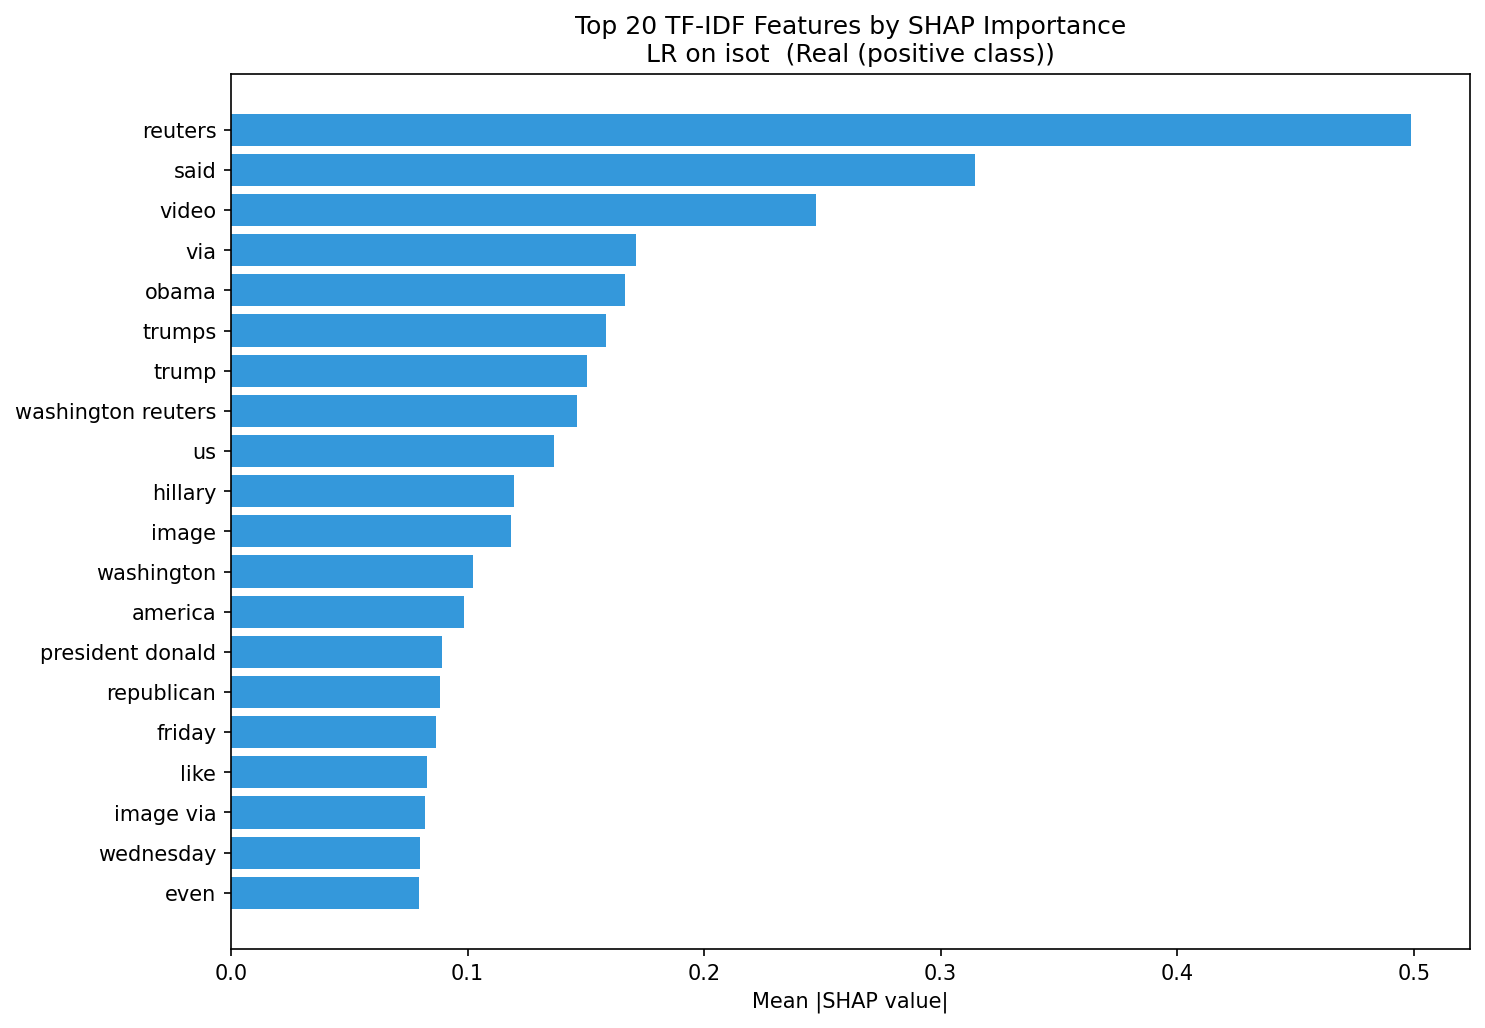

In [13]:
from IPython.display import Image, display
import os

shap_base = '../results/shap'

print("=== ISOT — LR: Global Feature Importance ===")
display(Image(os.path.join(shap_base, 'isot_lr', 'global_importance_top20.png'), width=700))

=== ISOT — LR: SHAP Beeswarm ===


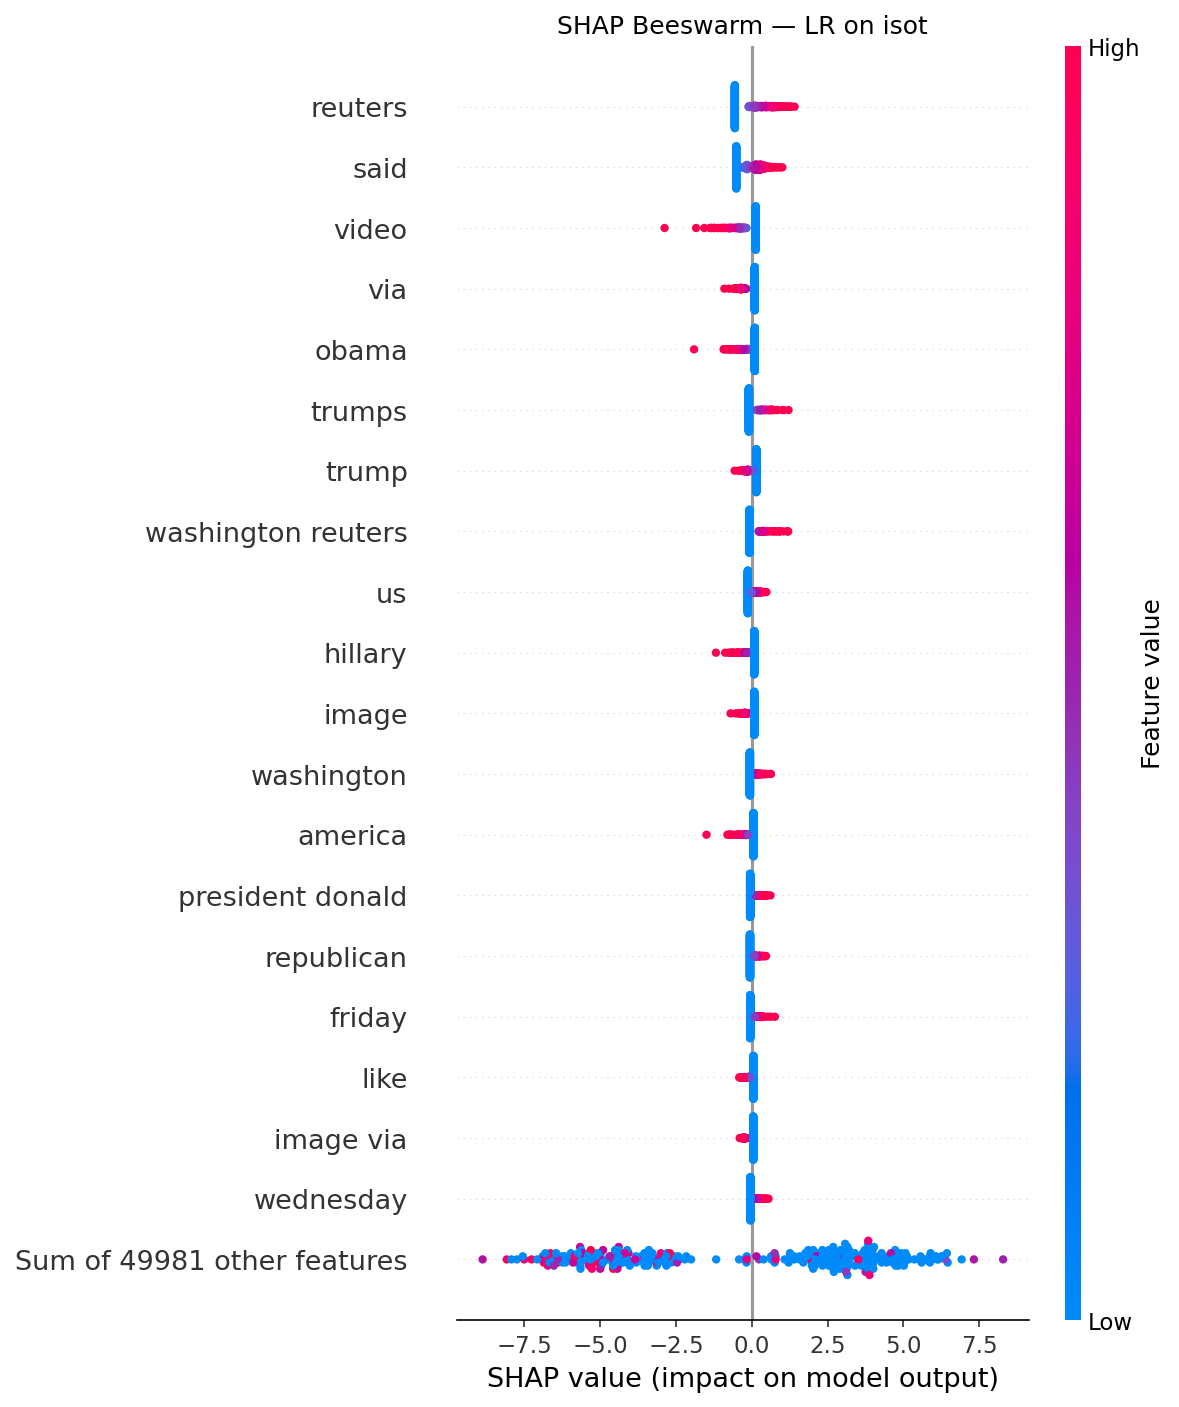

In [14]:
print("=== ISOT — LR: SHAP Beeswarm ===")
display(Image(os.path.join(shap_base, 'isot_lr', 'beeswarm.png'), width=700))

**ISOT SHAP finding:** The token `reuters` is the single highest-importance feature, with approximately twice the mean |SHAP value| of the next-highest feature. The model has learned a single rule: *does this article mention Reuters?* If yes, it is real; if no, it is more likely fake. This is not fake news detection — it is source identity detection.

This explains the 99.4%+ accuracy on ISOT (the signal is near-perfect) and the near-random cross-dataset transfer (WELFake's real articles also mention Reuters but with different context, and the fake articles differ from ISOT's fake class).

=== WELFake — LR: Global Feature Importance ===


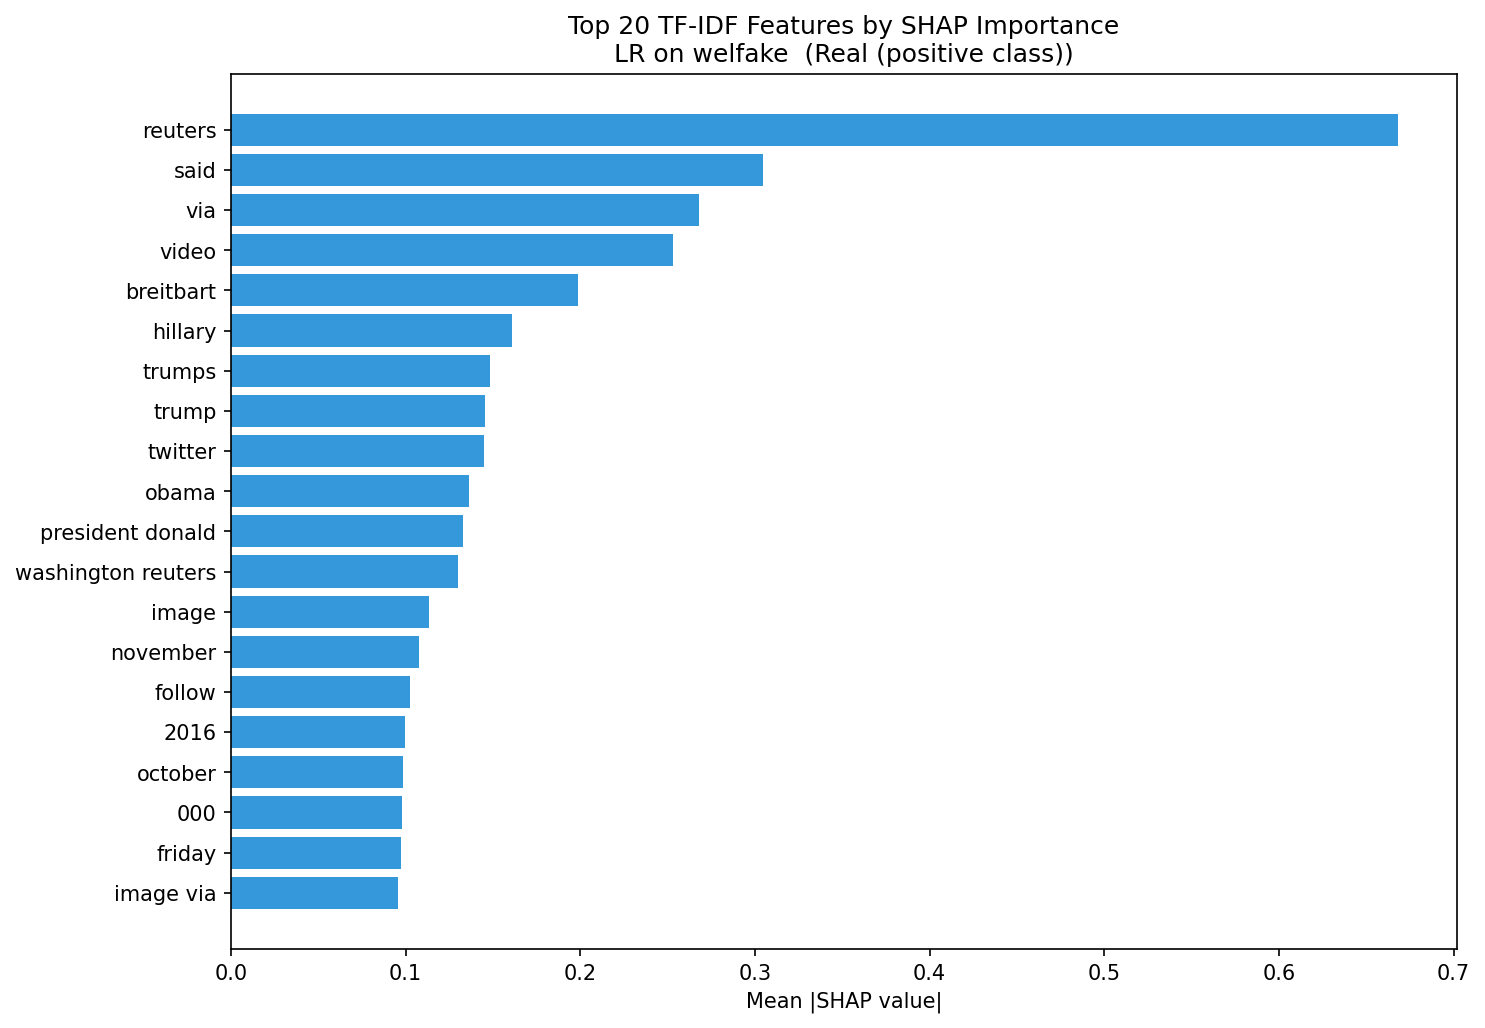

In [15]:
print("=== WELFake — LR: Global Feature Importance ===")
display(Image(os.path.join(shap_base, 'welfake_lr', 'global_importance_top20.png'), width=700))

=== Combined — LR: Global Feature Importance ===


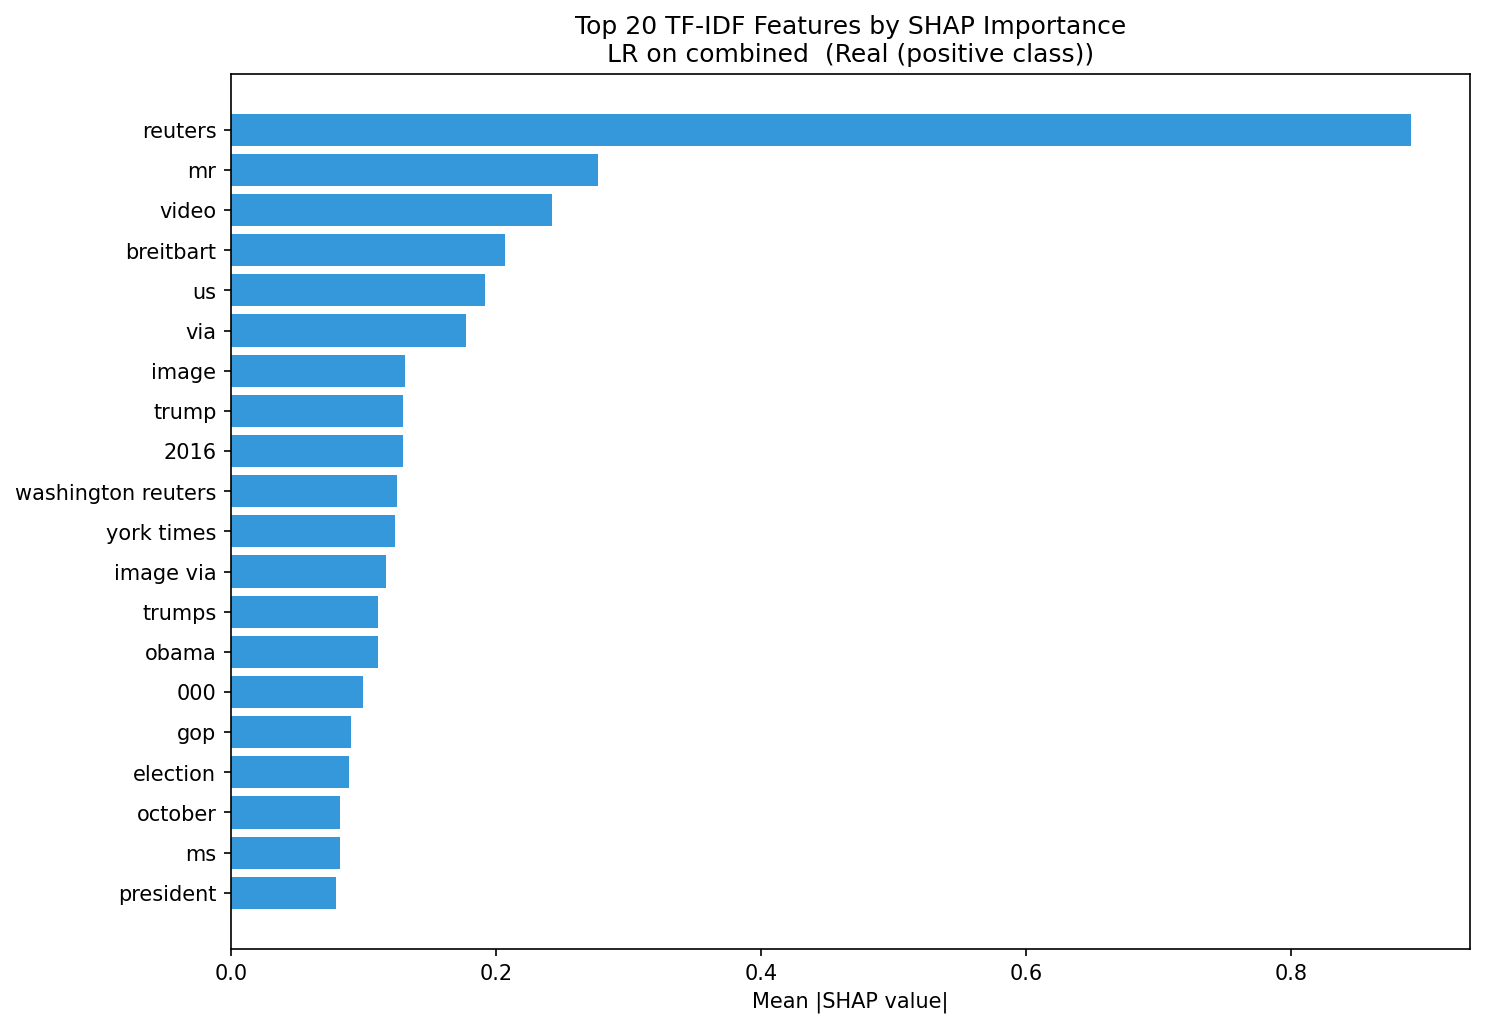

In [16]:
print("=== Combined — LR: Global Feature Importance ===")
display(Image(os.path.join(shap_base, 'combined_lr', 'global_importance_top20.png'), width=700))

**WELFake SHAP finding:** `reuters` remains a top feature but its dominance is reduced — reflecting WELFake's multi-source composition. More substantive linguistic features (political terms, names, journalism-specific vocabulary) begin appearing in the top-20.

**Combined SHAP finding:** Training on merged sources forces the model to weight more features. The combined model is harder to interpret via a single dominant signal, which is evidence that it has learned a broader representation — though cross-dataset transfer still fails (the Combined→WELFake ceiling at 0.385 proves the fundamental limit is dataset construction, not model capacity).

=== NELA-GT — LR: Global Importance — Class 0 (Reliable) ===


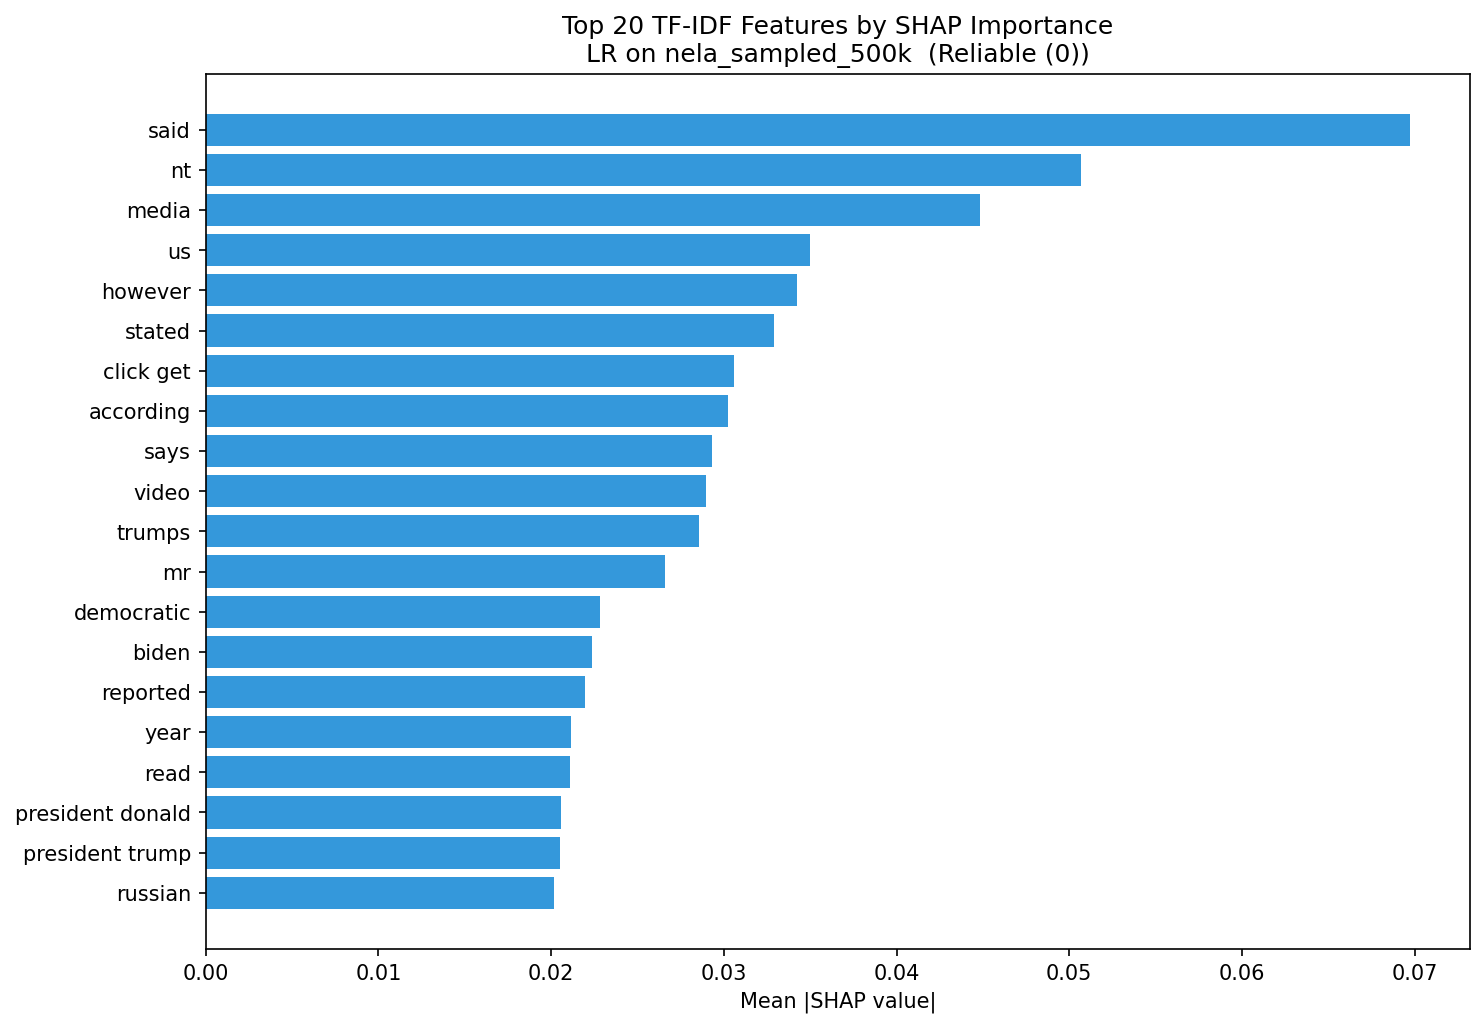

In [17]:
print("=== NELA-GT — LR: Global Importance — Class 0 (Reliable) ===")
display(Image(os.path.join(shap_base, 'nela_sampled_500k_lr', 'global_importance_top20_cls0.png'), width=700))

=== NELA-GT — LR: Global Importance — Class 1 (Questionable) ===


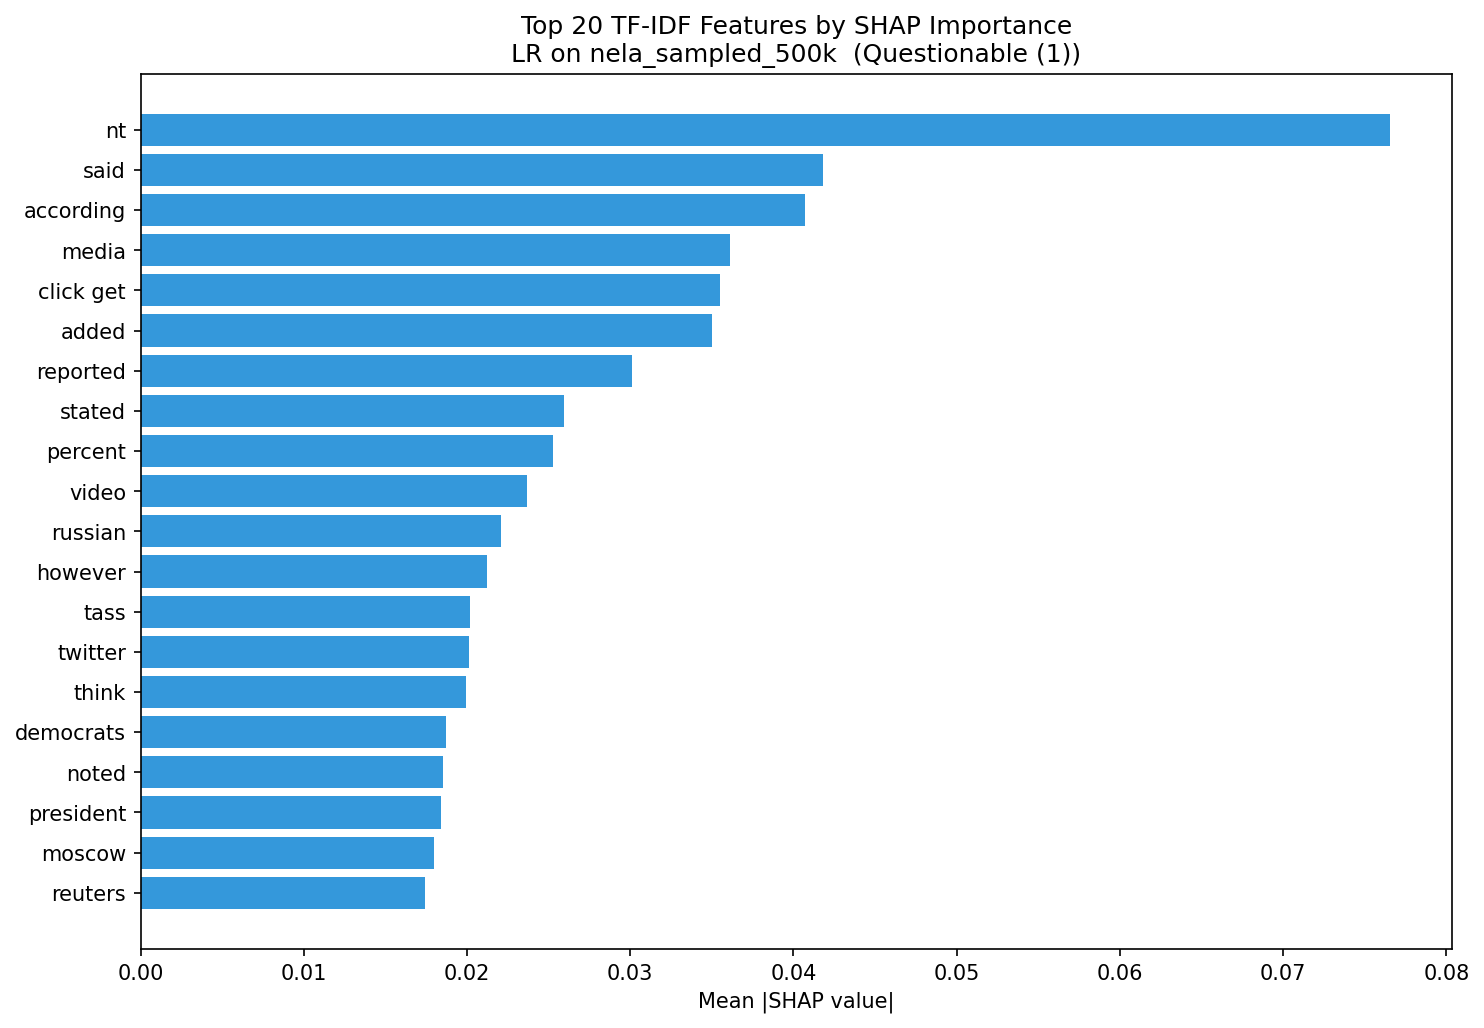

In [18]:
print("=== NELA-GT — LR: Global Importance — Class 1 (Questionable) ===")
display(Image(os.path.join(shap_base, 'nela_sampled_500k_lr', 'global_importance_top20_cls1.png'), width=700))

=== NELA-GT — LR: Global Importance — Class 2 (Conspiracy) ===


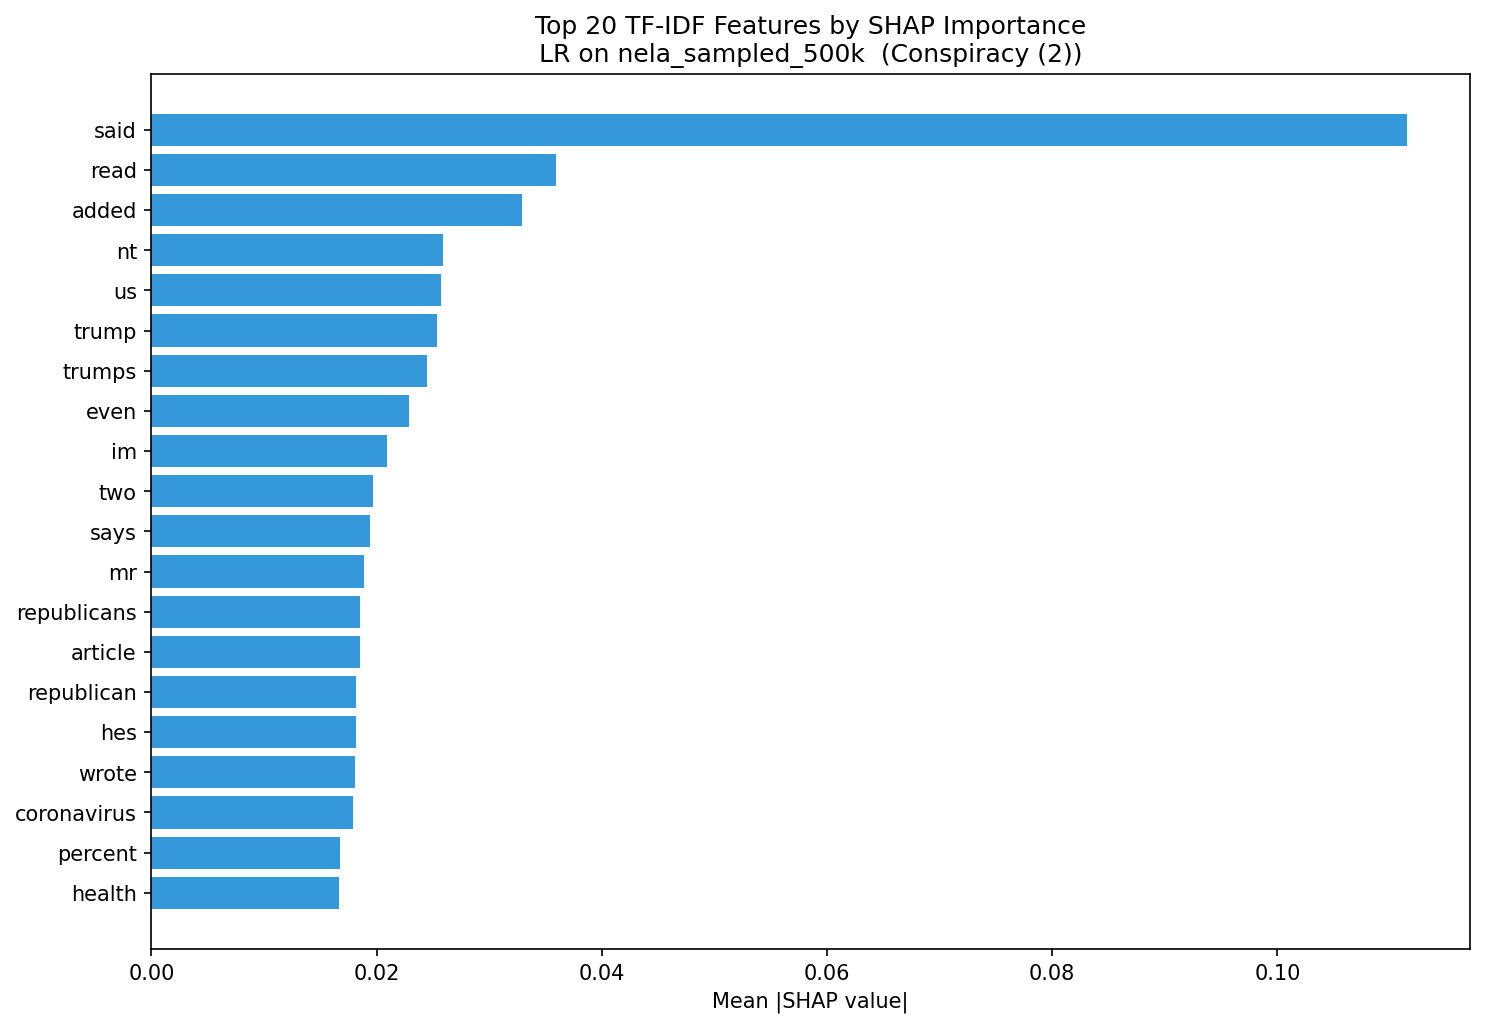

In [19]:
print("=== NELA-GT — LR: Global Importance — Class 2 (Conspiracy) ===")
display(Image(os.path.join(shap_base, 'nela_sampled_500k_lr', 'global_importance_top20_cls2.png'), width=700))

=== NELA-GT — LR: SHAP Beeswarm — Class 0 (Reliable) ===


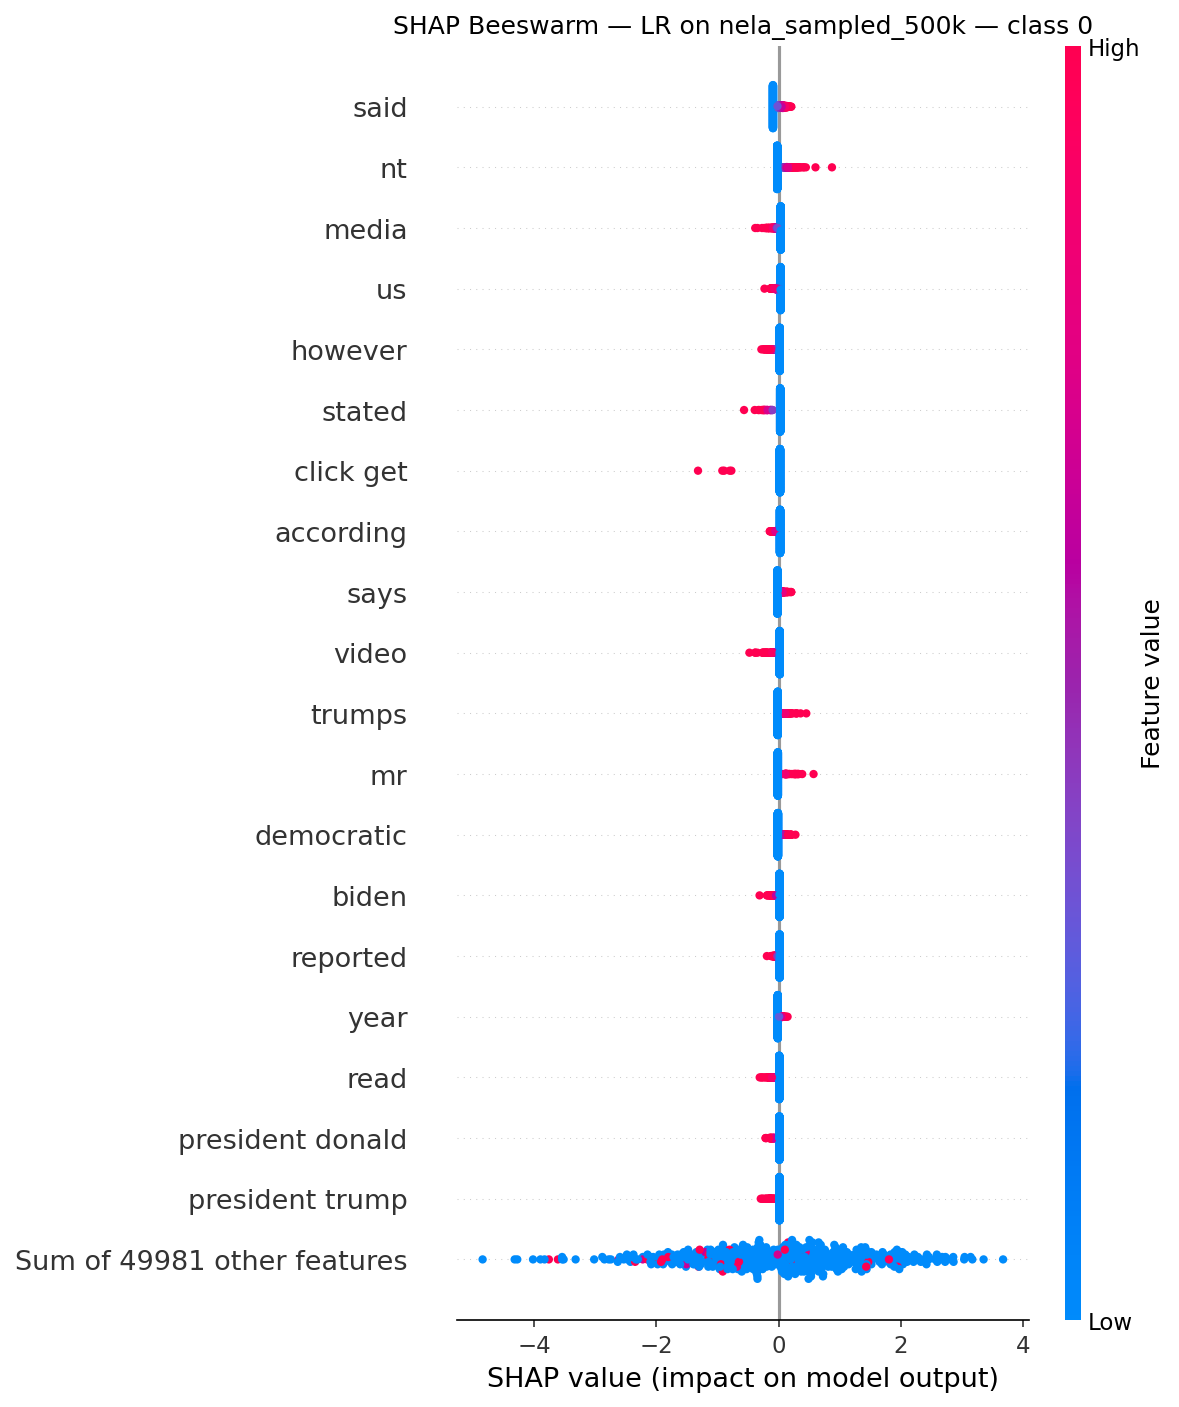

=== NELA-GT — LR: SHAP Beeswarm — Class 2 (Conspiracy) ===


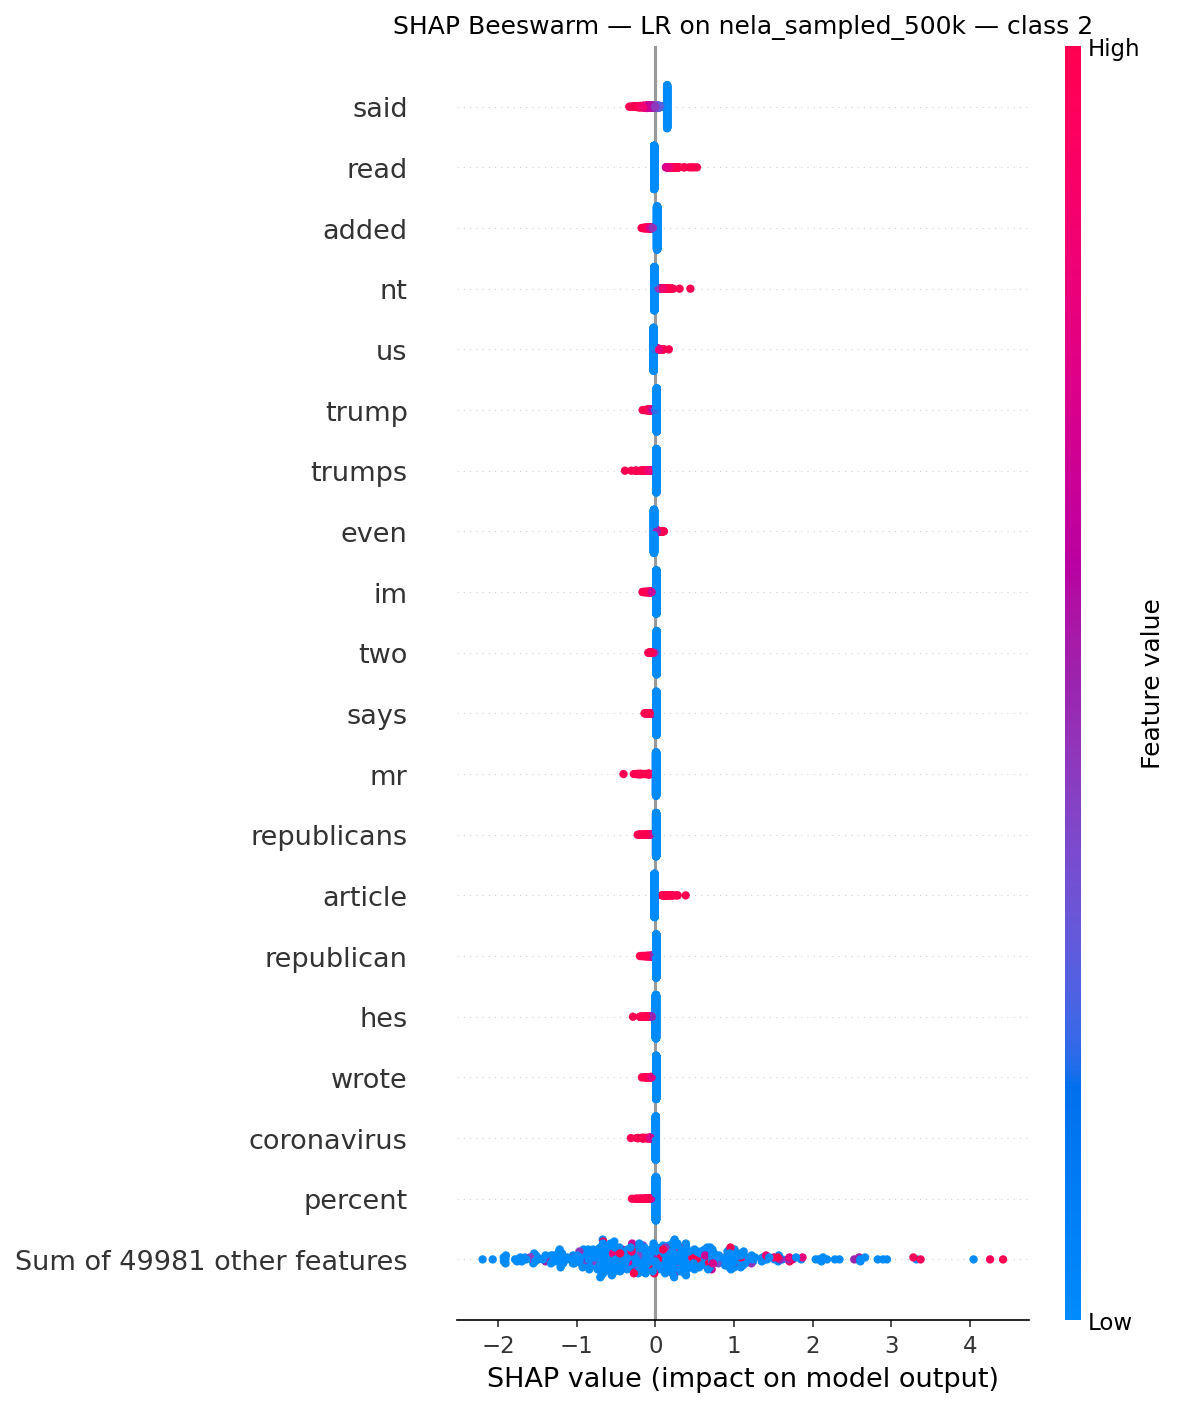

In [20]:
print("=== NELA-GT — LR: SHAP Beeswarm — Class 0 (Reliable) ===")
display(Image(os.path.join(shap_base, 'nela_sampled_500k_lr', 'beeswarm_cls0.png'), width=700))
print("=== NELA-GT — LR: SHAP Beeswarm — Class 2 (Conspiracy) ===")
display(Image(os.path.join(shap_base, 'nela_sampled_500k_lr', 'beeswarm_cls2.png'), width=700))

**NELA SHAP finding:** The NELA model produces interpretably different feature profiles per class. The Conspiracy class highlights topic-specific vocabulary (health/medical misinformation terms, political conspiracy language). The Reliable class emphasises professional journalism conventions. No single outlet name dominates — confirming that training across 457 sources eliminates the source-identity shortcut.

### 5.6 Latency and Efficiency

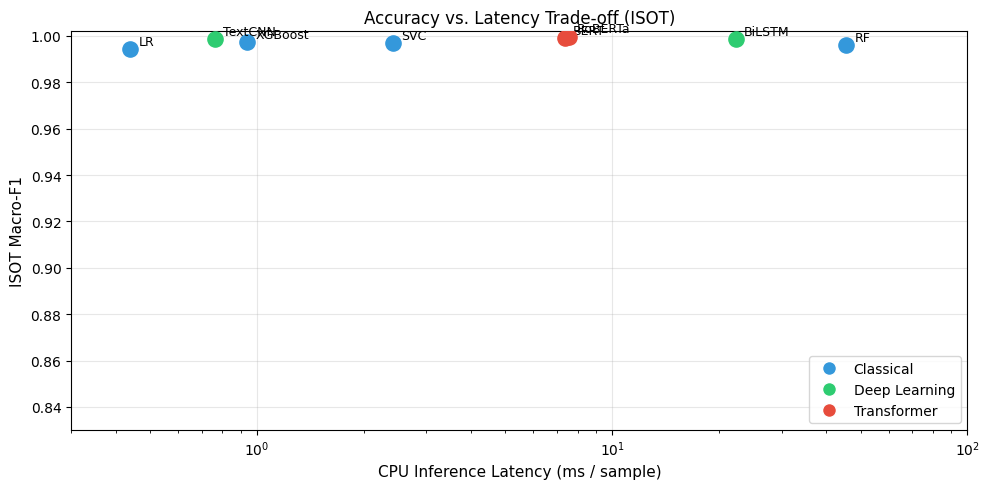

TextCNN offers the best latency/accuracy trade-off: 0.9985 F1 at 0.76ms


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

models = ['LR', 'XGBoost', 'SVC', 'TextCNN', 'BERT', 'RoBERTa', 'BiLSTM', 'RF']
latencies = [0.44, 0.94, 2.41, 0.76, 7.35, 7.54, 22.28, 45.50]
f1s = [0.9943, 0.9974, 0.9969, 0.9985, 0.9990, 0.9997, 0.9987, 0.9961]
tiers = ['Classical', 'Classical', 'Classical', 'Deep Learning',
         'Transformer', 'Transformer', 'Deep Learning', 'Classical']
colors = {'Classical': '#3498db', 'Deep Learning': '#2ecc71', 'Transformer': '#e74c3c'}

fig, ax = plt.subplots(figsize=(10, 5))
for m, lat, f1, tier in zip(models, latencies, f1s, tiers):
    ax.scatter(lat, f1, color=colors[tier], s=120, zorder=3)
    ax.annotate(m, (lat, f1), textcoords='offset points', xytext=(6, 3), fontsize=9)

ax.set_xlabel('CPU Inference Latency (ms / sample)', fontsize=11)
ax.set_ylabel('ISOT Macro-F1', fontsize=11)
ax.set_title('Accuracy vs. Latency Trade-off (ISOT)', fontsize=12)
ax.set_xscale('log')
ax.set_xlim(0.3, 100)
ax.set_ylim(0.83, 1.002)
ax.grid(True, alpha=0.3)

from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=10, label=t)
                   for t, c in colors.items()]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig('../results/latency_vs_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print("TextCNN offers the best latency/accuracy trade-off: 0.9985 F1 at 0.76ms")

**Latency findings:**
- **LR (0.44ms)** is the fastest model. Suitable for any real-time use case.
- **TextCNN (0.76ms)** offers nearly identical accuracy to BiLSTM on ISOT/WELFake with 30× faster inference — the best overall efficiency trade-off.
- **BERT/RoBERTa (~7.5ms)** are 10–17× slower than TextCNN with marginal accuracy gains on binary datasets where all models are already above 0.99.
- **RF (45ms)** is the slowest by far — ensemble tree inference does not benefit from the sparse TF-IDF representation as efficiently as linear models.

### 5.7 Summary Comparison

In [22]:
summary = {
    'Model': ['BiLSTM (NELA)', 'LR (NELA)', 'TextCNN (NELA)', 'SVC (NELA)',
               'LR (Combined)', 'RoBERTa (ISOT)', 'LR (ISOT)'],
    'NELA F1 (3-class)': [0.7458, 0.7179, 0.7241, 0.7095, '—', '—', '—'],
    'Cross-eval: NELA→ISOT': [0.5615, 0.5709, 0.5594, 0.5474, '—', '—', '—'],
    'PHEMEplus F1': [0.5068, 0.5029, 0.4898, 0.4959, 0.5059, 0.2729, 0.3054],
    'ISOT F1 (within)': ['—', '—', '—', '—', '—', 0.9997, 0.9943],
    'Latency (ms)': [21.82, 0.89, 0.76, 2.44, 0.47, 7.54, 0.44],
    'Recommended for': [
        'Best generaliser, batch processing',
        'Real-time, diverse sources',
        'Real-time, best efficiency ratio',
        'Real-time, balanced',
        'Combined binary, OOD tweets',
        'Within-domain accuracy focus',
        'Within-domain, lowest latency'
    ],
}
df_summary = pd.DataFrame(summary)
df_summary.style.set_caption('Overall Model Comparison and Recommendations') \
                .format(lambda x: f'{x:.4f}' if isinstance(x, float) else x)

,Model,NELA F1 (3-class),Cross-eval: NELA→ISOT,PHEMEplus F1,ISOT F1 (within),Latency (ms),Recommended for
0,BiLSTM (NELA),0.7458,0.5615,0.5068,—,21.8200,"Best generaliser, batch processing"
1,LR (NELA),0.7179,0.5709,0.5029,—,0.8900,"Real-time, diverse sources"
2,TextCNN (NELA),0.7241,0.5594,0.4898,—,0.7600,"Real-time, best efficiency ratio"
3,SVC (NELA),0.7095,0.5474,0.4959,—,2.4400,"Real-time, balanced"
4,LR (Combined),—,—,0.5059,—,0.4700,"Combined binary, OOD tweets"
5,RoBERTa (ISOT),—,—,0.2729,0.9997,7.5400,Within-domain accuracy focus
6,LR (ISOT),—,—,0.3054,0.9943,0.4400,"Within-domain, lowest latency"


---
## 6. Where — Storage and Deployment <a id='6-where'></a>

### 6.1 Artefact Storage

All project artefacts are version-controlled in a local Git repository (`news-classification/`) with the following layout:

```
news-classification/
├── data/
│   ├── raw/            # Original downloaded datasets
│   └── processed/      # Cleaned train/val/test CSVs per dataset
├── checkpoints/
│   ├── classical/      # Joblib files: {model}_best.joblib + TF-IDF vectoriser
│   ├── deep_learning/  # PyTorch .pt files per dataset
│   └── cache/          # TF-IDF vectoriser cache (keyed by model+dataset)
├── results/
│   ├── runs/           # Timestamped JSON per evaluation run
│   ├── aggregated_results.json
│   ├── results_table.md
│   └── shap/           # SHAP PNG plots per dataset+model
└── src/
    ├── classical/      # TF-IDF training, evaluation, SHAP
    ├── deep_learning/  # GloVe, BiLSTM, TextCNN
    ├── transformers_/  # BERT, RoBERTa
    ├── nela/           # NELA preprocessing, cross-eval
    ├── pheme/          # PHEME/PHEMEplus loader
    └── utils/          # Config, metrics, data loader, results aggregator
```

### 6.2 Colab Training Artefacts

NELA deep learning models (BiLSTM, TextCNN) were trained on Google Colab A100 GPU. Checkpoints, vocabulary files, and result JSONs are persisted to Google Drive (`/content/drive/MyDrive/news-classification/`) using symlinks, and copied to the local repository for final aggregation.

### 6.3 Reproducibility

All training scripts accept `--dataset` and `--model` CLI flags. The results aggregator (`python -m src.utils.results_aggregator --all`) reads all `results/runs/*.json` files and produces the Markdown and CSV summary tables. A random seed of 42 is set globally in `src/utils/config.py`.

**Execution commands:**
```bash
# Classical models on ISOT
python -m src.classical.train --dataset isot --model lr svc rf xgb

# Deep learning on WELFake
python -m src.deep_learning.train --dataset welfake

# Transformers on combined
python -m src.transformers_.train --dataset combined --model bert roberta

# NELA preprocessing + sampling
python -m src.nela.dataset --preprocess --sample 500000

# NELA cross-eval (all tiers)
python -m src.nela.eval --tier all --target all --pheme phemeplus

# SHAP analysis
python -m src.classical.explain --dataset isot --model lr xgb --n-top 20

# Aggregate results
python -m src.utils.results_aggregator --all
```

---
## 7. Experiences — Reflections and Future Work <a id='7-experiences'></a>

### 7.1 What Worked Well

**The cross-dataset probe design was the most valuable decision.** Running every model in a train-on-A, evaluate-on-B protocol — before seeing any within-dataset results — would have revealed the source-fingerprinting problem immediately. Instead, starting with within-dataset results produced a misleading picture of near-perfect accuracy that took the SHAP analysis to explain. Designing for generalisation from the start should be the default for any detection system research.

**NELA-GT genuinely improved generalisation.** The hypothesis that source diversity would reduce the fingerprinting shortcut was confirmed: NELA-trained LR scored 0.57 on ISOT cross-eval vs 0.26 for ISOT-trained models — a factor-of-two improvement. The SHAP plots corroborated this: no single outlet name dominated the NELA model's feature importance.

**Modular code structure paid off.** Separating dataset loaders, feature extractors, model definitions, training loops, and evaluation into independent modules made it straightforward to add NELA as a new dataset without modifying the transformer or DL training logic (only `num_classes` needed to propagate).

**LIAR metadata finding was the most surprising result.** The +0.23 F1 lift from adding structured metadata to LR was larger than the total spread between the weakest and strongest text-only model. This was not anticipated at the project outset and changes the interpretation of LIAR results substantially.

### 7.2 What Didn't Work / Challenges

**Memory management for NELA was a repeated challenge.** The 4.2M article corpus exceeded available RAM at multiple stages: loading all years for deduplication (13 GB merged CSV), the initial parallel preprocessing with too many workers, and the 3-pass subsampling. Each required a different streaming solution:
- Parallel shard processing with RAM-capped worker count (psutil-based)
- Streaming hash-set deduplication without ever loading the full merged file
- 3-pass reservoir sampling using only integer row indices in memory

**RF failed on NELA** despite the `max_features='sqrt'` fix. The combination of 400,000 rows, 50,000 features, and the minority Conspiracy class (~8%) pushed RF to near-random on Conspiracy. The underlying issue is that ensemble trees require dense partitioning of the feature space, which is expensive and ineffective at this scale.

**WELFake→ISOT near-zero F1 was initially alarming.** The 0.000–0.004 score looked like a code bug. Investigation confirmed it is genuine: WELFake-trained models learn to predict one class for everything on ISOT because the datasets have incompatible label semantics. This required careful explanation in results tables to avoid misleading readers.

**Transformers were not evaluated on NELA.** The 512-token sequence limit and 400,000 training rows would require 3–4 days of fine-tuning on the available hardware. This is the most significant gap in the evaluation — transformer cross-dataset generalisation on NELA could be an important data point.

### 7.3 What Could Be Improved

**Hyperparameter tuning** was minimal — most models used default or lightly tuned hyperparameters. A systematic grid search with cross-validation would potentially improve RF and XGB on NELA.

**Publisher-stratified evaluation** on NELA would produce more interpretable generalisation results. The current train/val/test split is article-level; a publisher-level split (train on publishers A–350, test on publishers 351–457) would more strictly test whether the model learns publisher-independent signals.

### 7.4 Lessons Learned

1. **High within-dataset accuracy is not evidence of a working fake news detector.** It is evidence that the training data has a strong shortcut signal. Always evaluate cross-dataset.
2. **Dataset construction is the primary lever.** Model architecture matters less than training data diversity. The gap between ISOT-trained LR (0.26 cross-eval) and NELA-trained LR (0.57 cross-eval) is not explained by any model property — it is entirely explained by training data source diversity.
3. **LIAR and article-level fake news are different tasks.** Conflating them in benchmarks produces misleading conclusions about transformer capabilities.
4. **Streaming is necessary for large corpora.** Any corpus exceeding ~1 GB should be processed in streaming chunks; `pandas.read_csv` on multi-GB files is a silent OOM risk.

### 7.5 Future Work

**1. Evaluate against AI-generated fake news.** Models trained on human-authored articles may not generalise to LLM-generated misinformation, which tends to be stylistically indistinguishable from professional journalism. Testing on datasets like RAID or HC3 would reveal this gap.

**2. Zero-shot LLM comparison.** Modern large language models (Claude, GPT-4) can reason about content credibility via prompting without any task-specific training. Comparing their zero-shot macro-F1 against the best fine-tuned models in this study would calibrate how much of the remaining performance gap is addressable by scale alone.

**3. Publisher-stratified corpus construction.** The NELA results suggest that source diversity is the correct axis to optimise. A purpose-built dataset that uniformly samples across publishers at all reliability levels — with equal representation of genres, topics, and political orientations — would provide a more honest benchmark than either ISOT or WELFake.

**4. Multi-modal detection.** Article text alone misses images, video, and social engagement signals that human fact-checkers routinely use. A system that jointly encodes headline, body text, article images, and sharing metadata would be substantially more robust and better reflects the information available at moderation time.

**5. Transformer evaluation on NELA.** Fine-tuning BERT or RoBERTa on the 500k NELA sample on a high-memory GPU (A100 80GB) and evaluating its cross-dataset transfer would complete the tier comparison begun in this study.

---

## References

- Vosoughi, S., Roy, D., & Aral, S. (2018). The spread of true and false news online. *Science*, 359(6380), 1146–1151.
- Ahmed, H., Traore, I., & Saad, S. (2018). Detecting opinion spams and fake news using text classification. *Security and Privacy*, 1(1), e9. [ISOT dataset]
- Verma, P. K., Agrawal, P., Amorim, I., & Prodan, R. (2021). WELFake: Word embedding over linguistic features for fake news detection. *IEEE Transactions on Computational Social Systems*, 8(4), 881–893.
- Wang, W. Y. (2017). "Liar, Liar Pants on Fire": A new benchmark dataset for fake news detection. *ACL 2017*.
- Gruppi, M., Horne, B. D., & Adalı, S. (2022). NELA-GT-2022: A Large Multi-Labelled News Dataset for The Study of Misinformation in News Articles. *arXiv:2203.05659*.
- Zubiaga, A., Liakata, M., Procter, R., Bontcheva, K., & Tolmie, P. (2016). Analysing how people orient to and spread rumours in social media by looking at conversational threads. *PLOS ONE*, 11(3).
- Lundberg, S. M., & Lee, S.-I. (2017). A unified approach to interpreting model predictions. *NeurIPS 2017*. [SHAP]
- Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). BERT: Pre-training of deep bidirectional transformers for language understanding. *NAACL 2019*.
- Liu, Y., et al. (2019). RoBERTa: A robustly optimized BERT pretraining approach. *arXiv:1907.11692*.